In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("unipoint_survey.csv")

In [2]:
df = df.drop(columns=["Score"])
df

,Timestamp,"Are you a student of the University of Sindh, Jamshoro?",Full Name,Gender,Department/Faculty,Semester,Year,Age Group,Study Program,"From which area do you travel to the university? (Example: Latifabad #7, Qasimabad, Old Campus, Market etc.)",How do you usually travel?,How many UniPoint pick-up points are available in your area?,Why don’t you use UniPoint?,Does a UniPoint stop exist near your area?,Do you think UniPoint should increase the number of UniPoints to solve timing issues or expand routes to cover more residential areas?,Email Address,How do you rate the condition and punctuality of UniPoint buses?,Any suggestions or feedback for UniPoint management?,Complete Roll Number (for example 2K10/CSE/60)
0,10/18/2025 17:48:59,Yes,Usama,Male,Information Technology,6,3rd,18–22,BS,Jamshoro Society,UniPoint (University Transport),2.0,NaN,NaN,Yes,uk9040535@gmail.com,1.0,"In over area, jamshoro society phase 1, only 2...",2K23/IT/166
1,10/18/2025 18:07:00,Yes,Syeda Barkat,Female,Data Science,6,3rd,18–22,BS,Gulshan e Zeal Pak Society,UniPoint (University Transport),2.0,NaN,NaN,Yes,syedabarkat.1@gmail.com,1.0,Please Grant Offical uni buses to every area l...,2K23/DS/98
2,10/18/2025 18:24:39,Yes,Muhammad Nawaz,Male,Data science,6,3rd,23–26,BS,etc,Public Transport (Bus/Rickshaw),NaN,Timing issues,Yes,Yes,m09618233@gmail.com,NaN,Official point 1 bajha se start ki jae,2k23/DS/64
3,10/18/2025 18:26:01,Yes,Sharique shaikh,Male,IT,4,2nd,23–26,BS,Latifabad #7,UniPoint (University Transport),1.0,NaN,NaN,Yes,shaikh.sharique56@gmail.com,1.0,The university transport system needs serious ...,2k24/DS/86
4,10/18/2025 18:27:01,Yes,Vikram Kumar,Male,Data Science (FET),6,3rd,18–22,BS,Naseem nagr choke,UniPoint (University Transport),4.0,NaN,NaN,Yes,amateur2k04@gmail.com,1.0,Uni point management should have to increase n...,2K23/DS/100
5,10/18/2025 18:27:12,Yes,Abdul Rafiu,Male,Data science,4,2nd,18–22,BS,Society,Personal Transport (Car/Bike),NaN,Comfort/convenience,No,Maybe,rafioabdul72@gmail.com,NaN,More Uni point,2K24/DS/6
6,10/18/2025 18:29:23,Yes,Mudasir,Male,Faculty of Engineering and technology,4,2nd,18–22,Data Science,I travel from citizens colony,UniPoint (University Transport),1.0,NaN,NaN,Yes,mudasirlashari2005@gmail.com,3.0,They should make punctuality of time and make ...,Mudasir
7,10/18/2025 18:50:10,Yes,Mubashir Hussain,Male,Anthropology and Archaeology,7,4th,23–26,BS,Channel,UniPoint (University Transport),1.0,NaN,NaN,Maybe,mpanhwar541@gmail.com,3.0,NaN,2K22/AA/25
8,10/18/2025 19:41:21,Yes,Mujtaba Asif,Male,Bs(Data science),6,3rd,18–22,BS,Afandi town,UniPoint (University Transport),3.0,NaN,NaN,Yes,mujtabamemon456@gmail.com,1.0,Afandi town pr sirf boys k liya ak hi ata he o...,2K23/DS/75
9,10/18/2025 20:00:07,Yes,Javeria,Female,Data Science,6,3rd,23–26,BS,Latifabad # 5,UniPoint (University Transport),4.0,NaN,NaN,Yes,khanjaveriaa23@gmail.com,1.0,NaN,2K23/DS/42


In [3]:
df.columns.tolist()

['Timestamp',
 'Are you a student of the University of Sindh, Jamshoro?',
 'Full Name',
 'Gender',
 'Department/Faculty',
 'Semester',
 'Year',
 'Age Group',
 'Study Program',
 'From which area do you travel to the university? (Example: Latifabad #7, Qasimabad, Old Campus, Market etc.)',
 'How do you usually travel?',
 'How many UniPoint pick-up points are available in your area?',
 'Why don’t you use UniPoint?',
 'Does a UniPoint stop exist near your area?',
 'Do you think UniPoint should increase the number of UniPoints to solve timing issues or expand routes to cover more residential areas?',
 'Email Address',
 'How do you rate the condition and punctuality of UniPoint buses?',
 'Any suggestions or feedback for UniPoint management?',
 'Complete Roll Number (for example 2K10/CSE/60)']

In [4]:
df = df.rename(columns={"Are you a student of the University of Sindh, Jamshoro?": "Student",
                        "From which area do you travel to the university? (Example: Latifabad #7, Qasimabad, Old Campus, Market etc.)": "Area",
                        "How do you usually travel?": "Mode of Transport",
                        "How many UniPoint pick-up points are available in your area?": "No. of Pick-up Points",
                        "Why don’t you use UniPoint?": "Reason",
                        "Does a UniPoint stop exist near your area?": "UniPoint Near Area",
                        "Do you think UniPoint should increase the number of UniPoints to solve timing issues or expand routes to cover more residential areas?": "Increase/Expand",
                        "How do you rate the condition and punctuality of UniPoint buses?": "Rating",
                        "Any suggestions or feedback for UniPoint management?": "Suggestions",
                        "Complete Roll Number (for example 2K10/CSE/60)": "Roll Number"
                        })
df.head()


,Timestamp,Student,Full Name,Gender,Department/Faculty,Semester,Year,Age Group,Study Program,Area,Mode of Transport,No. of Pick-up Points,Reason,UniPoint Near Area,Increase/Expand,Email Address,Rating,Suggestions,Roll Number
0,10/18/2025 17:48:59,Yes,Usama,Male,Information Technology,6,3rd,18–22,BS,Jamshoro Society,UniPoint (University Transport),2.0,NaN,NaN,Yes,uk9040535@gmail.com,1.0,"In over area, jamshoro society phase 1, only 2...",2K23/IT/166
1,10/18/2025 18:07:00,Yes,Syeda Barkat,Female,Data Science,6,3rd,18–22,BS,Gulshan e Zeal Pak Society,UniPoint (University Transport),2.0,NaN,NaN,Yes,syedabarkat.1@gmail.com,1.0,Please Grant Offical uni buses to every area l...,2K23/DS/98
2,10/18/2025 18:24:39,Yes,Muhammad Nawaz,Male,Data science,6,3rd,23–26,BS,etc,Public Transport (Bus/Rickshaw),NaN,Timing issues,Yes,Yes,m09618233@gmail.com,NaN,Official point 1 bajha se start ki jae,2k23/DS/64
3,10/18/2025 18:26:01,Yes,Sharique shaikh,Male,IT,4,2nd,23–26,BS,Latifabad #7,UniPoint (University Transport),1.0,NaN,NaN,Yes,shaikh.sharique56@gmail.com,1.0,The university transport system needs serious ...,2k24/DS/86
4,10/18/2025 18:27:01,Yes,Vikram Kumar,Male,Data Science (FET),6,3rd,18–22,BS,Naseem nagr choke,UniPoint (University Transport),4.0,NaN,NaN,Yes,amateur2k04@gmail.com,1.0,Uni point management should have to increase n...,2K23/DS/100


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Timestamp              50 non-null     object 
 1   Student                50 non-null     object 
 2   Full Name              50 non-null     object 
 3   Gender                 50 non-null     object 
 4   Department/Faculty     50 non-null     object 
 5   Semester               50 non-null     int64  
 6   Year                   50 non-null     object 
 7   Age Group              50 non-null     object 
 8   Study Program          50 non-null     object 
 9   Area                   50 non-null     object 
 10  Mode of Transport      50 non-null     object 
 11  No. of Pick-up Points  42 non-null     float64
 12  Reason                 5 non-null      object 
 13  UniPoint Near Area     6 non-null      object 
 14  Increase/Expand        50 non-null     object 
 15  Email Ad

In [6]:
le = LabelEncoder()
df["Student"] = le.fit_transform(df["Student"])
df["Gender"] = le.fit_transform(df["Gender"])

df.head()

,Timestamp,Student,Full Name,Gender,Department/Faculty,Semester,Year,Age Group,Study Program,Area,Mode of Transport,No. of Pick-up Points,Reason,UniPoint Near Area,Increase/Expand,Email Address,Rating,Suggestions,Roll Number
0,10/18/2025 17:48:59,0,Usama,1,Information Technology,6,3rd,18–22,BS,Jamshoro Society,UniPoint (University Transport),2.0,NaN,NaN,Yes,uk9040535@gmail.com,1.0,"In over area, jamshoro society phase 1, only 2...",2K23/IT/166
1,10/18/2025 18:07:00,0,Syeda Barkat,0,Data Science,6,3rd,18–22,BS,Gulshan e Zeal Pak Society,UniPoint (University Transport),2.0,NaN,NaN,Yes,syedabarkat.1@gmail.com,1.0,Please Grant Offical uni buses to every area l...,2K23/DS/98
2,10/18/2025 18:24:39,0,Muhammad Nawaz,1,Data science,6,3rd,23–26,BS,etc,Public Transport (Bus/Rickshaw),NaN,Timing issues,Yes,Yes,m09618233@gmail.com,NaN,Official point 1 bajha se start ki jae,2k23/DS/64
3,10/18/2025 18:26:01,0,Sharique shaikh,1,IT,4,2nd,23–26,BS,Latifabad #7,UniPoint (University Transport),1.0,NaN,NaN,Yes,shaikh.sharique56@gmail.com,1.0,The university transport system needs serious ...,2k24/DS/86
4,10/18/2025 18:27:01,0,Vikram Kumar,1,Data Science (FET),6,3rd,18–22,BS,Naseem nagr choke,UniPoint (University Transport),4.0,NaN,NaN,Yes,amateur2k04@gmail.com,1.0,Uni point management should have to increase n...,2K23/DS/100


In [7]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())



Timestamp:
['10/18/2025 17:48:59' '10/18/2025 18:07:00' '10/18/2025 18:24:39'
 '10/18/2025 18:26:01' '10/18/2025 18:27:01' '10/18/2025 18:27:12'
 '10/18/2025 18:29:23' '10/18/2025 18:50:10' '10/18/2025 19:41:21'
 '10/18/2025 20:00:07' '10/18/2025 22:18:51' '10/18/2025 23:31:47'
 '10/19/2025 0:09:46' '10/19/2025 0:20:33' '10/19/2025 1:11:14'
 '10/19/2025 1:42:13' '10/19/2025 1:45:43' '10/19/2025 1:46:59'
 '10/19/2025 2:03:48' '10/19/2025 2:06:50' '10/19/2025 2:12:58'
 '10/19/2025 3:11:33' '10/19/2025 4:39:22' '10/19/2025 6:00:47'
 '10/19/2025 7:11:47' '10/19/2025 7:51:11' '10/19/2025 9:46:56'
 '10/19/2025 10:10:02' '10/19/2025 10:10:47' '10/19/2025 10:29:42'
 '10/19/2025 10:57:12' '10/19/2025 11:16:27' '10/19/2025 12:42:48'
 '10/19/2025 12:47:06' '10/19/2025 12:49:40' '10/19/2025 12:53:17'
 '10/19/2025 12:57:01' '10/19/2025 13:02:21' '10/19/2025 13:02:39'
 '10/19/2025 13:07:41' '10/19/2025 13:22:38' '10/19/2025 13:28:32'
 '10/19/2025 13:30:03' '10/19/2025 13:50:42' '10/19/2025 14:04:10

In [8]:
print(df.info())
print(df.describe(include='all'))
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Timestamp              50 non-null     object 
 1   Student                50 non-null     int64  
 2   Full Name              50 non-null     object 
 3   Gender                 50 non-null     int64  
 4   Department/Faculty     50 non-null     object 
 5   Semester               50 non-null     int64  
 6   Year                   50 non-null     object 
 7   Age Group              50 non-null     object 
 8   Study Program          50 non-null     object 
 9   Area                   50 non-null     object 
 10  Mode of Transport      50 non-null     object 
 11  No. of Pick-up Points  42 non-null     float64
 12  Reason                 5 non-null      object 
 13  UniPoint Near Area     6 non-null      object 
 14  Increase/Expand        50 non-null     object 
 15  Email Ad

In [9]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Reason"] = df["Reason"].fillna("Not Applicable")
df["UniPoint Near Area"] = df["UniPoint Near Area"].fillna("Not Applicable")
df["Suggestions"] = df["Suggestions"].fillna("No suggestion")
df["No. of Pick-up Points"] = df["No. of Pick-up Points"].fillna(df["No. of Pick-up Points"].median())

df["Rating"] = df["Rating"].astype(int)
df["No. of Pick-up Points"] = df["No. of Pick-up Points"].astype(int)

print(df[["Rating", "No. of Pick-up Points"]].dtypes)
df.head()

Rating                   int64
No. of Pick-up Points    int64
dtype: object


,Timestamp,Student,Full Name,Gender,Department/Faculty,Semester,Year,Age Group,Study Program,Area,Mode of Transport,No. of Pick-up Points,Reason,UniPoint Near Area,Increase/Expand,Email Address,Rating,Suggestions,Roll Number
0,10/18/2025 17:48:59,0,Usama,1,Information Technology,6,3rd,18–22,BS,Jamshoro Society,UniPoint (University Transport),2,Not Applicable,Not Applicable,Yes,uk9040535@gmail.com,1,"In over area, jamshoro society phase 1, only 2...",2K23/IT/166
1,10/18/2025 18:07:00,0,Syeda Barkat,0,Data Science,6,3rd,18–22,BS,Gulshan e Zeal Pak Society,UniPoint (University Transport),2,Not Applicable,Not Applicable,Yes,syedabarkat.1@gmail.com,1,Please Grant Offical uni buses to every area l...,2K23/DS/98
2,10/18/2025 18:24:39,0,Muhammad Nawaz,1,Data science,6,3rd,23–26,BS,etc,Public Transport (Bus/Rickshaw),2,Timing issues,Yes,Yes,m09618233@gmail.com,2,Official point 1 bajha se start ki jae,2k23/DS/64
3,10/18/2025 18:26:01,0,Sharique shaikh,1,IT,4,2nd,23–26,BS,Latifabad #7,UniPoint (University Transport),1,Not Applicable,Not Applicable,Yes,shaikh.sharique56@gmail.com,1,The university transport system needs serious ...,2k24/DS/86
4,10/18/2025 18:27:01,0,Vikram Kumar,1,Data Science (FET),6,3rd,18–22,BS,Naseem nagr choke,UniPoint (University Transport),4,Not Applicable,Not Applicable,Yes,amateur2k04@gmail.com,1,Uni point management should have to increase n...,2K23/DS/100


In [10]:
df.to_csv("cleaned_unipoint_data.csv", index=False)
df2 = pd.read_csv("cleaned_unipoint_data.csv")
df2.head()

,Timestamp,Student,Full Name,Gender,Department/Faculty,Semester,Year,Age Group,Study Program,Area,Mode of Transport,No. of Pick-up Points,Reason,UniPoint Near Area,Increase/Expand,Email Address,Rating,Suggestions,Roll Number
0,10/18/2025 17:48:59,0,Usama,1,Information Technology,6,3rd,18–22,BS,Jamshoro Society,UniPoint (University Transport),2,Not Applicable,Not Applicable,Yes,uk9040535@gmail.com,1,"In over area, jamshoro society phase 1, only 2...",2K23/IT/166
1,10/18/2025 18:07:00,0,Syeda Barkat,0,Data Science,6,3rd,18–22,BS,Gulshan e Zeal Pak Society,UniPoint (University Transport),2,Not Applicable,Not Applicable,Yes,syedabarkat.1@gmail.com,1,Please Grant Offical uni buses to every area l...,2K23/DS/98
2,10/18/2025 18:24:39,0,Muhammad Nawaz,1,Data science,6,3rd,23–26,BS,etc,Public Transport (Bus/Rickshaw),2,Timing issues,Yes,Yes,m09618233@gmail.com,2,Official point 1 bajha se start ki jae,2k23/DS/64
3,10/18/2025 18:26:01,0,Sharique shaikh,1,IT,4,2nd,23–26,BS,Latifabad #7,UniPoint (University Transport),1,Not Applicable,Not Applicable,Yes,shaikh.sharique56@gmail.com,1,The university transport system needs serious ...,2k24/DS/86
4,10/18/2025 18:27:01,0,Vikram Kumar,1,Data Science (FET),6,3rd,18–22,BS,Naseem nagr choke,UniPoint (University Transport),4,Not Applicable,Not Applicable,Yes,amateur2k04@gmail.com,1,Uni point management should have to increase n...,2K23/DS/100


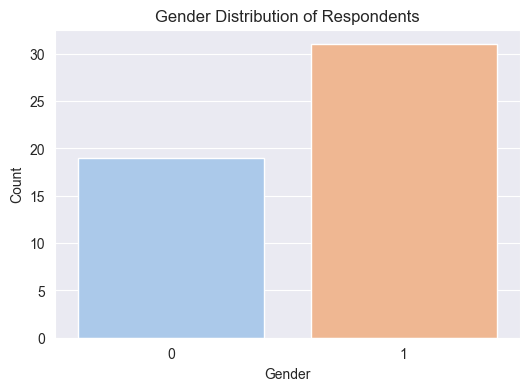

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, hue='Gender', palette='pastel', legend=False)
plt.title("Gender Distribution of Respondents")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


Average Rating: 2.0


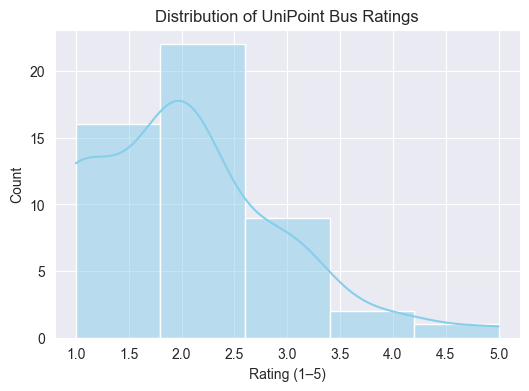

In [12]:
print("Average Rating:", df["Rating"].mean())

plt.figure(figsize=(6,4))
sns.histplot(df['Rating'], kde=True, bins=5, color='skyblue')
plt.title("Distribution of UniPoint Bus Ratings")
plt.xlabel("Rating (1–5)")
plt.ylabel("Count")
plt.show()

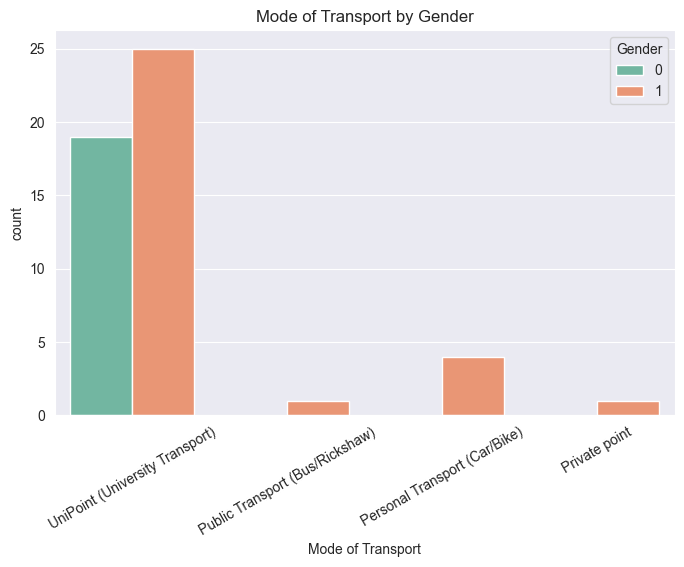

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Mode of Transport', data=df, hue='Gender', palette='Set2')
plt.title("Mode of Transport by Gender")
plt.xticks(rotation=30)
plt.show()

In [14]:
print(df.groupby("Area")["No. of Pick-up Points"].mean().round().astype(int))


Area
Afandi town                         3
Al Fateh Town Near Honda Palace     1
Behar colony kotri jamshoro         4
Block B, M.U.E.C.H.S, Jamshoro      1
Channel                             1
City gate Heerabad Hyderabad        1
Gulshan e Zeal Pak Society          2
I travel from citizens colony       1
Jamshoro Society                    2
Jamshoro Wapda Colony               1
Khosar latifbaad                    2
Khuda ki basti site kotri           4
Kohsar                              2
Kotri                               2
Kotri city                          2
Latifabad # 5                       4
Latifabad # 5 Latifabad             4
Latifabad #5                        2
Latifabad #7                        1
Latifabad 1                         2
Latifabad 12                        2
Latifabad#5                         3
Market                              1
Mirpurkhas                          3
Naseem nagar                        1
Naseem nagr choke                   4
Old Cam